# Estimarea Pretului pentru Procesoare

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from IPython.display import Markdown

plt.style.use("ggplot")
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

Pentru [df_bench](../data/CPU_benchmark_v4.csv) datele au fost descarcate din: [CPU Benchmarks Compilation](https://www.kaggle.com/datasets/alanjo/cpu-benchmarks)

In [13]:
df = pd.read_csv(r"..\data\CPU_benchmark_v4.csv")

# df.head(20)
# df.isna().sum()
# df.shape
# df.dtypes
# df.describe()

# df["TDP"].value_counts().head(10).plot(kind="barh")
# df["price"].plot(kind="hist", bins=100)

# df["price"].plot(kind="kde") 
# sns.pairplot(df, vars=[""])

# df.plot(kind="scatter", x="TDP", y="price", alpha=0.7)

# Curatarea datelor
Setul de date descarcat din [CPU Benchmarks Compilation](https://www.kaggle.com/datasets/alanjo/cpu-benchmarks) are nevoie de urmatoarele curatari:
-   campul `price` este evaluat in dolari, asa ca trebuie sa convertim din USD in RON.
-   din cauza ca producatorul se afla in numele procesorului, se va creia un camp nou numit `manufacturer` in care va fi separat.
-   incat campurile derivate nu ne intereseaza din setul de date (de ex. campul `cpuValue` este format din `cpuMark / price`) acestea vor fi scoase.
-   campurile care nu contin date in `price` vor fi folosite ca date pentru testarea predictiei, lafel cu procesoarele din fisierul [CPU_r23_v2.csv](../data/CPU_r23_v2.csv)


In [14]:
RATA_RON_USD = 4.39

df['manufacturer'] = df['cpuName'].apply(lambda x: str(x).split()[0] if pd.notnull(x) else 'Unknown')
df['price'] = df['price'] * RATA_RON_USD
df['log_price'] = np.log1p(df['price'])
df = df[[
    'manufacturer',
    'log_price',
    'cpuName', 
    'price', 
    'cpuMark', 
    # 'cpuValue', 
    'threadMark', 
    # 'threadValue',
    'TDP', 
    # 'powerPerf', 
    'cores', 
    # 'testDate', 
    # 'socket', 
    'category',
    # 'match_name'
    ]].copy()
# df.head()
# df.dtypes


# plt.figure(figsize=(10, 6))
# sns.scatterplot(data=df, x='price', y='multiScore', hue='manufacturer', style='category', alpha=0.7)
# plt.title('CPU Value: Price vs. Multi-core Performance (cpuMark)')
# plt.xscale('log') # Log scale is often better for price since it ranges from $50 to $7000+
# plt.show()

# plt.figure(figsize=(10, 6))
# sns.barplot(data=df, x='TDP', y='multiScore', hue='manufacturer', alpha=0.7)
# plt.title('Power Efficiency: TDP vs. Performance (sized by core count)')
# plt.show()
df_corr = df.dropna(subset=['price'])

# Analiza exploratorie
Din cauza ca diferenta intre media preturilor si mediana acestora este mare (706.79 vs. 1938) sugereaza ca datele sunt distribuite asimetric spre stanga. Din acest motiv in model se va aplica log() pe pret pentru al aduce mai aproape de o curba gaussiana.

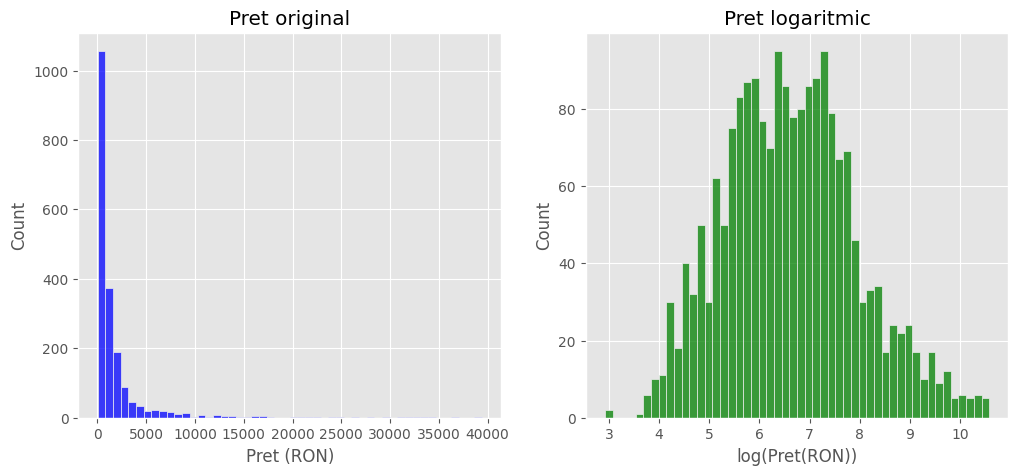

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['price'], bins=50, ax=axes[0], color='blue')
axes[0].set_title('Pret original')
axes[0].set_xlabel('Pret (RON)')

sns.histplot(df['log_price'], bins=50, ax=axes[1], color='green')
axes[1].set_title('Pret logaritmic')
axes[1].set_xlabel('log(Pret(RON))')

plt.show() # diferenta intre graficul original si cel logaritmic

### Correlatie
Pentru a putea afla care factori influenteaza cel mai tare pretul, se va observa urmatorul heatmap.
Din acest heatmap putem extrage urmatoarele rezultate:
-   Pretul este cel mai tare corelat cu scorul de performanta din benchmark, care este un rezultat asteptat.
-   Numarul de nuclee are o corelatie puternica cu pretul, mai puternica ca `threadMark` (performanta pe un singur nucleu).
-   Intre TPD si threadMark corelatia este destul de mica, asa ca mai multa putere nu inseamna cresterea performantei pe un singur nucleu.

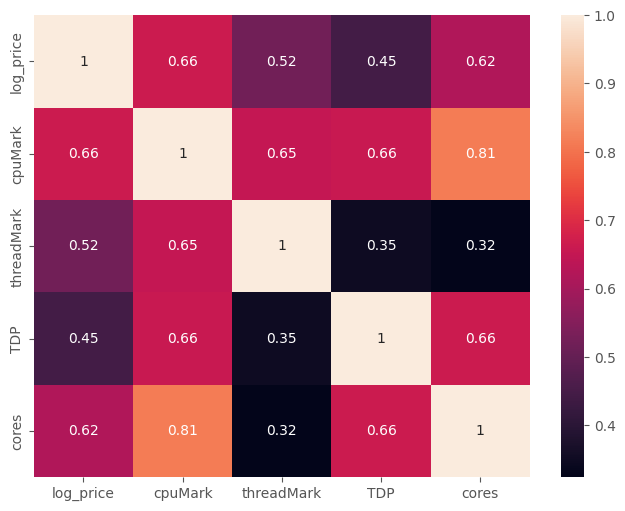

In [16]:
plt.figure(figsize=(8, 6))
df = df.drop('price', axis=1) # pentru ca folosim pretul logaritmic, scoatem pretul original
sns.heatmap(data=df.corr(numeric_only=True), annot=True)
plt.show()
